# Sophronia : Example of how to access the Sophronia hits

January 2026

* [IC socumentation](https://next-exp-sw.readthedocs.io/en/latest/index.html#)
* [Sophronia documentaion](https://next-exp-sw.readthedocs.io/en/latest/sophronia.html)

In [1]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

import warnings
warnings.filterwarnings("ignore")

In [2]:
import glob
import sys
from os import listdir
from collections import namedtuple
import itertools as itertools

In [3]:
import numpy             as np
import pandas            as pd
import tables            as tb
from   scipy             import stats
from   scipy             import optimize
import networkx as nx

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import axes3d

plt.rcParams['image.cmap'] = 'rainbow'

In [ ]:
#datafilename = 'dataset_15607_DEP_deco.h5'
#mcfilename   = 'dataset_4bar_MC_DEP_deco.h5'
data_path = "/mnt/netapp1/Store_next_data/NEXT100/data"
filename  = "/15607/hdf5/prod/v2.3.1/20250717/sophronia/trigger2/ldc1/run_15607_0000_ldc1_trg2.v2.3.1.20250717.HEDesman.sophronia.h5"

In [5]:
## Inspect the structure of the data files
with tb.open_file(data_path + filename, 'r') as h5in:
    print(h5in)

/mnt/netapp1/Store_next_data/NEXT100/data/15607/hdf5/prod/v2.3.1/20250717/sophronia/trigger2/ldc1/run_15607_0000_ldc1_trg2.v2.3.1.20250717.HEDesman.sophronia.h5 (File) ''
Last modif.: 'Tue Jul 22 09:49:51 2025'
Object Tree: 
/ (RootGroup) ''
/DB (Group) ''
/DB/DataPMT (Table(60,), shuffle, zlib(4)) 'DB constants for PMTs'
/DB/DataSiPM (Table(3584,), shuffle, zlib(4)) 'DB constants for SiPMs'
/DST (Group) ''
/DST/Events (Table(90,), shuffle, zlib(4)) 'KDST Events'
/Filters (Group) ''
/Filters/s12_selector (Table(30,), shuffle, zlib(4)) 'Event has passed filter flag'
/Filters/valid_hit (Table(30,), shuffle, zlib(4)) 'Event has passed filter flag'
/RECO (Group) ''
/RECO/Events (Table(46240,), shuffle, zlib(4)) 'Hits'
/Run (Group) ''
/Run/events (Table(30,), shuffle, zlib(4)) 'event info table'
/Run/runInfo (Table(30,), shuffle, zlib(4)) 'run info table'



In [6]:
hits = pd.read_hdf(data_path + filename, 'RECO/Events')

In [7]:
hits

,event,time,npeak,Xpeak,Ypeak,nsipm,X,Y,Xrms,Yrms,Z,Q,E,Qc,Ec,track_id,Ep
0,15,1.752993e+09,36,72.292775,69.919261,1,-235.825,-402.175,0.0,0.0,724.462375,8.049496,-0.486855,-1.0,-0.000004,-1,-1.0
1,15,1.752993e+09,36,72.292775,69.919261,1,-3.575,414.975,0.0,0.0,724.462375,6.255112,-0.378326,-1.0,-0.000002,-1,-1.0
2,15,1.752993e+09,36,72.292775,69.919261,1,257.775,-340.475,0.0,0.0,724.462375,5.950277,-0.359889,-1.0,-0.000002,-1,-1.0
3,15,1.752993e+09,36,72.292775,69.919261,1,319.975,-418.225,0.0,0.0,724.462375,7.132378,-0.431385,-1.0,NaN,-1,-1.0
4,15,1.752993e+09,36,72.292775,69.919261,1,366.625,-324.925,0.0,0.0,724.462375,6.428333,-0.388803,-1.0,NaN,-1,-1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46235,799,1.752993e+09,16,102.292332,57.301917,1,10.975,-202.025,0.0,0.0,954.075000,5.032396,1.417026,-1.0,0.000007,-1,-1.0
46236,799,1.752993e+09,16,102.292332,57.301917,1,335.525,90.925,0.0,0.0,954.075000,5.170661,1.455959,-1.0,0.000008,-1,-1.0
46237,799,1.752993e+09,16,102.292332,57.301917,1,396.725,90.925,0.0,0.0,954.075000,6.200910,1.746057,-1.0,0.000010,-1,-1.0
46238,799,1.752993e+09,16,102.292332,57.301917,1,73.175,-124.275,0.0,0.0,957.075250,5.583076,2.610012,-1.0,0.000014,-1,-1.0


In [6]:
pypaths = ('/home/usc/ie/jhm/NEXT/nextana',
           '/home/usc/ie/jhm/NEXT/hipy', 
           '/home/usc/ie/jjhm/NEXT/IC')
for ipypath in pypaths:
       sys.path.insert(0,ipypath)

In [7]:
from nana.topo.evtdisp  import plot_2d_bins as p2d
import nana.topo.evtfun    as evtfun
import nana.topo.graphfun  as graphfun
import nana.topo.zora      as zora

In [8]:
import hipy.utils        as ut

#import hipy.histos       as histos
import hipy.pltext       as pltext
#import hipy.profile      as prof
#from invisible_cities.io.dst_io import load_dst, load_dsts
from hipy.styles import style

## Load Data

In [10]:
datafilename = 'dataset_15607_DEP_deco.h5'
mcfilename   = 'dataset_4bar_MC_DEP_deco.h5'
datapath     = '/mnt/netapp1/Store_next_data/NEXT100/deco_seg/'

In [11]:
ifilename = datapath + mcfilename
print(f'loading {ifilename}')
data     =  pd.read_hdf(ifilename, 'DATASET/Voxels');
bin_info =  pd.read_hdf(ifilename, 'DATASET/BinsInfo');
#bin_widths  = evtfun.get_bin_widths(bin_info)

loading /mnt/netapp1/Store_next_data/NEXT100/deco_seg/dataset_4bar_MC_DEP_deco.h5


In [19]:
data.head()

,dataset_id,binclass,xbin,ybin,zbin,energy,decolabel,decoscore,decopred,segclass,extlabel
0,0,0,37,51,52,0.000402,0,0.009006,0,2,0
1,0,0,38,43,52,0.000832,0,0.017880,0,2,0
2,0,0,38,44,52,0.000463,0,0.013932,0,2,0
3,0,0,38,47,52,0.000436,0,0.009499,0,2,0
4,0,0,38,47,53,0.000938,0,0.011403,0,2,0


In [20]:
data_ = data[data.dataset_id <= 30]

In [21]:
datadeco   = evtfun.get_deconvoluted_data(data_)
#evtfun.test_get_deconvoluted_data(data)

In [22]:
datadeco

,dataset_id,binclass,xbin,ybin,zbin,energy,decolabel,decoscore,decopred,segclass,extlabel,enecc,enecn
0,0,0,37,51,52,0.000402,0,0.009006,0,2,0,0.000000,0.000000
1,0,0,38,43,52,0.000832,0,0.017880,0,2,0,0.000000,0.000000
2,0,0,38,44,52,0.000463,0,0.013932,0,2,0,0.000000,0.000000
3,0,0,38,47,52,0.000436,0,0.009499,0,2,0,0.000000,0.000000
4,0,0,38,47,53,0.000938,0,0.011403,0,2,0,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10894,30,0,50,58,57,0.000395,0,0.031487,0,2,0,0.000000,0.000000
10895,30,0,51,55,57,0.001877,0,0.091136,0,2,0,0.000000,0.000000
10896,30,0,51,56,56,0.001468,0,0.217680,1,2,0,0.002311,0.002311
10897,30,0,51,56,57,0.002837,0,0.220297,1,2,0,0.004527,0.004527


## Event loop

In [23]:
groupid = 'dataset_id'
evtdata = datadeco.groupby(groupid)

In [24]:
ievt = 21
evt = evtdata.get_group(ievt)
evt.head()

,dataset_id,binclass,xbin,ybin,zbin,energy,decolabel,decoscore,decopred,segclass,extlabel,enecc,enecn
7357,21,0,20,61,41,0.000578,0,0.126006,0,1,0,0.0,0.0
7358,21,0,21,60,41,0.001494,0,0.309520,0,1,0,0.0,0.0
7359,21,0,21,60,42,0.001292,0,0.259938,0,1,0,0.0,0.0
7360,21,0,21,60,43,0.000510,0,0.072644,0,1,0,0.0,0.0
7361,21,0,21,61,41,0.001895,0,0.415625,0,1,0,0.0,0.0


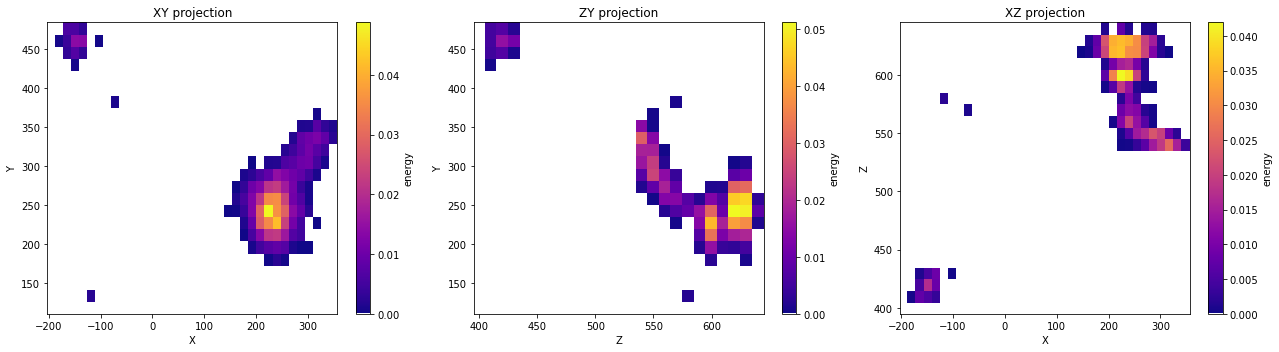

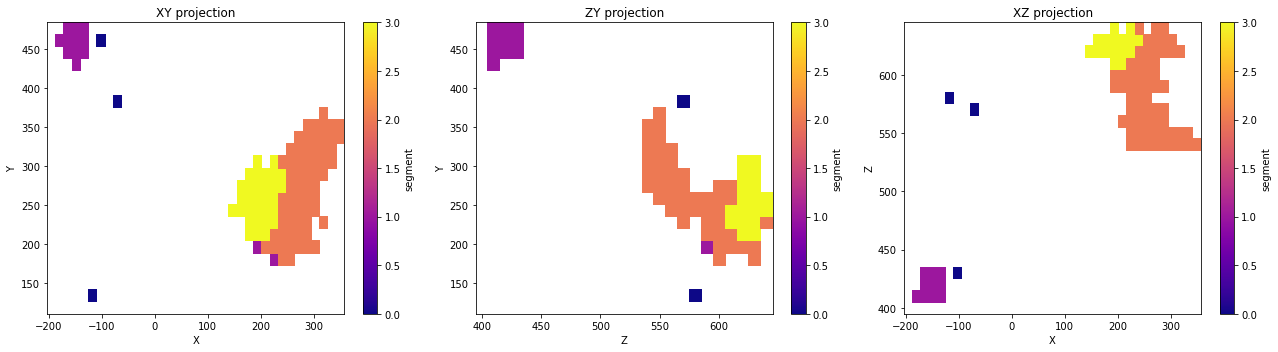

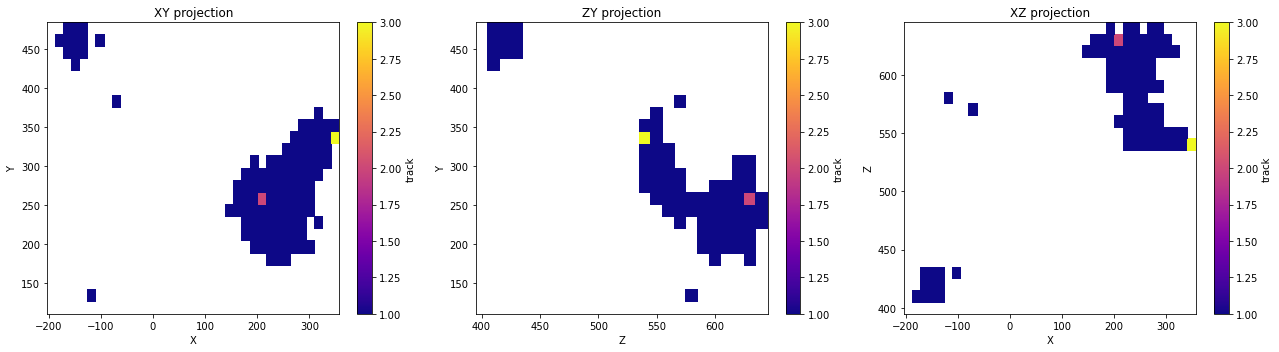

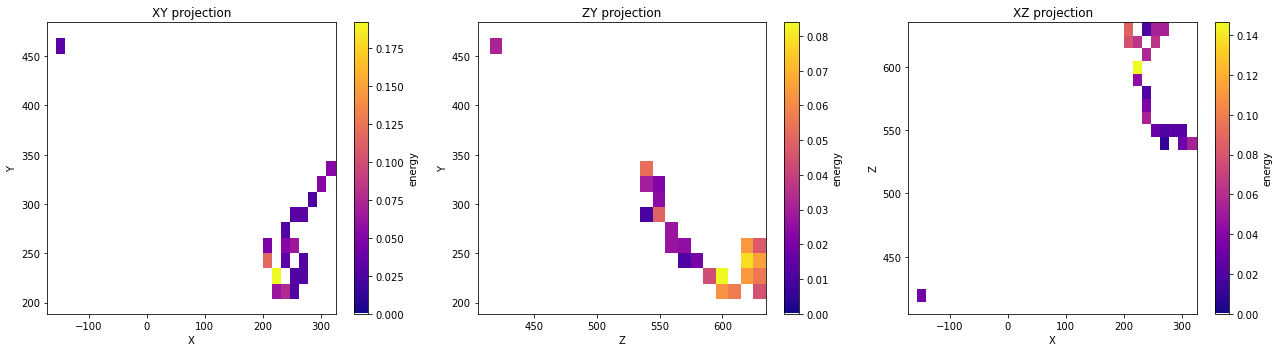

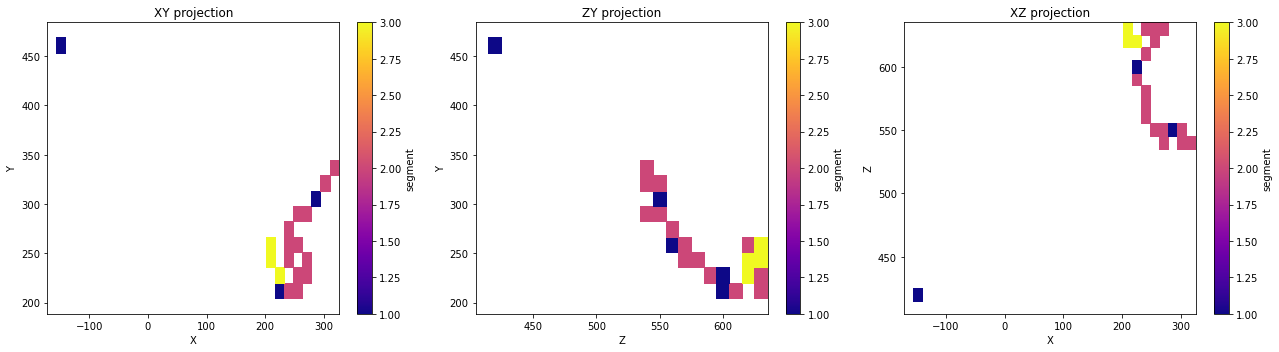

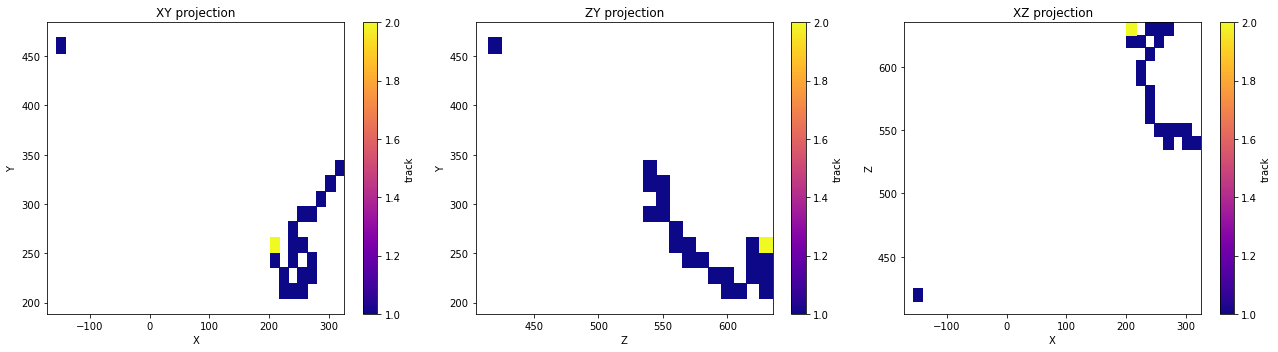

In [25]:
cc = evtfun.display_event(evt, bin_info, 'energy')
cc = evtfun.display_event(evt, bin_info, 'enecn')

No handles with labels found to put in legend.


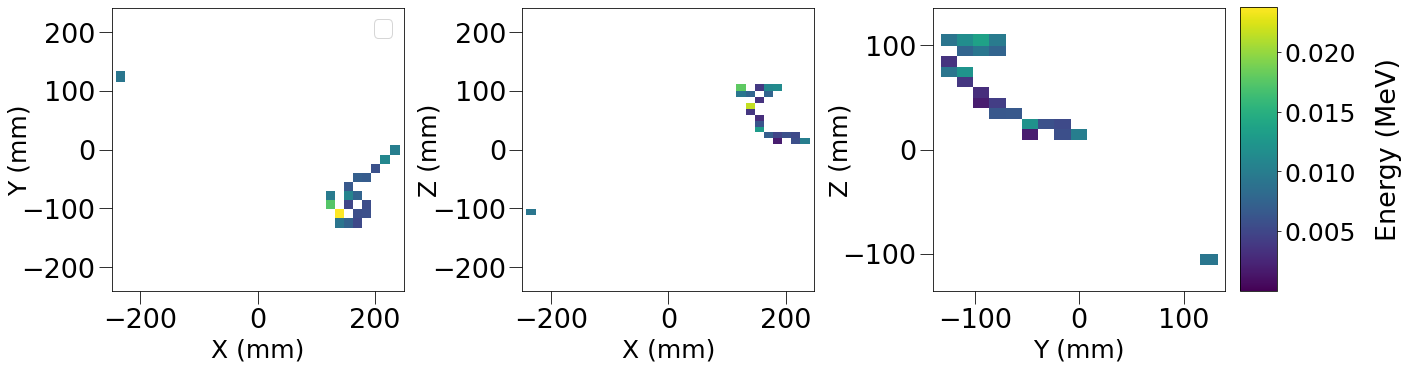

In [24]:
p2d(evt, bin_info)

340 1.0


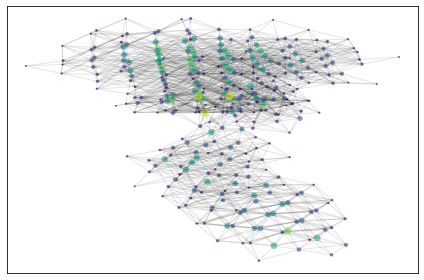

In [26]:
ename = 'energy'
g = graphfun.convert_to_graph_direct(evt, bin_info, ename)
print(len(g.nodes()), graphfun.graph_energy(g))
graphfun.display_graph(g)

27 1.0000000000000002


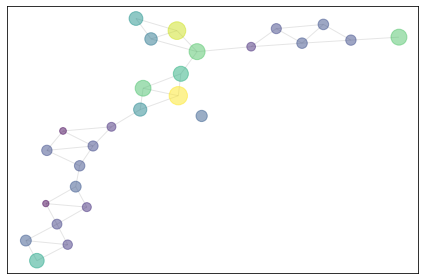

In [27]:
ename = 'enecn'
g = graphfun.convert_to_graph_direct(evt, bin_info, ename)
print(len(g.nodes()), graphfun.graph_energy(g))
graphfun.display_graph(g)

<function hipy.pltext.canvas.<locals>.subplot(iplot: int, dim: str = '2d')>

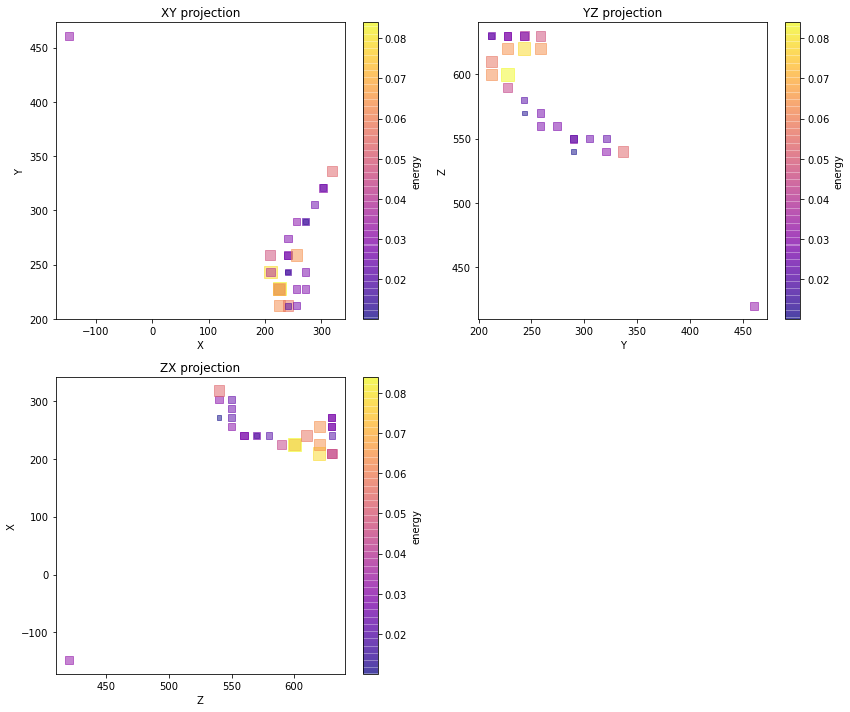

In [28]:
graphfun.display_graph_scatter(g)

In [35]:
esum = evtfun.summary_event(evt)

graph, graphs, longest_graph = graphfun.get_graphs(evt, bin_info, ename = 'enecn')
extremes, distance           = graphfun.get_extremes(longest_graph)
blobs, extremes, blobs_ene   = graphfun.get_blobs_radius(longest_graph, extremes)

tgraph, tgraphs, longest_tgraph, bgraphs, egraphs = graphfun.get_mcgraphs(evt, bin_info)
#emcsum = graphfun.summary_mcext(longest_graph, extremes, blobs, egrpa)


In [39]:
print(extremes, distance)

((48, 48, 62), (52, 53, 54)) 15


In [38]:
extremes2, distance2         = graphfun.get_extremes_from_mc(longest_graph, egraphs)

[NodeView(((45, 48, 63),)), NodeView(((54, 53, 54),))]


In [41]:
esum   = graphfun.summary_extremes(longest_graph, extremes, distance)
emcsum = graphfun.summary_mcextremes(longest_graph, extremes, egraphs) 
esum.update(emcsum)
print(esum)

{'ext_ene': [0.06370111525851471, 0.05325740234957067], 'ext_degree': [3, 4], 'ext_dist': [15, 15], 'mcext_ext': [47.70977363182523, 31.100000000000023]}


In [49]:
xpos   = [longest_graph.nodes[node]['position'] for node in extremes]
xmcpos = [[egraph[node]['position'] for node in egraph.nodes()] for egraph in egraphs]

print(xpos)
print(xmcpos)

KeyError: 'position'

In [23]:
extremes, distance = graphfun.graph_extremes(longest_graph)

In [274]:
blobs, extremes, blobs_ene = graphfun.get_blobs(longest_graph, extremes)

In [275]:
graphfun.graph_energy(blobs[1])

0.05325740234957067

In [276]:
bsum = graphfun.summary_blobs(longest_graph, extremes, distance, blobs, blobs_ene)

In [277]:
bsum

{'ext_ene': [0.06370111525851471, 0.05325740234957067],
 'ext_degree': [3, 4],
 'ext_dist': [15, 15],
 'blob_id': [0, 1],
 'blob_ene': [0.06370111525851471, 0.05325740234957067],
 'blob_nodes': [1, 1],
 'blob_edges': [1, 1]}

In [278]:
cc = graphfun.summary_mcext(longest_graph, extremes, blobs, egraphs)

In [279]:
cc

{'mcext_ext': [47.70977363182523, 31.100000000000023],
 'mcext_blob': [47.70977363182523, 31.100000000000023]}

In [178]:
blobs = [blobfun.get_blob(longest_graph, extreme, radius = 21.) for extreme in extremes]

In [179]:
blobs[1].nodes(data = True)

NodeDataView({(28, 35, 23): {'energy': 0.001015692, 'position': array([-55.  ,  56.55, 230.  ])}, (28, 35, 22): {'energy': 0.00081474957, 'position': array([-55.  ,  56.55, 220.  ])}, (27, 35, 22): {'energy': 0.00048247693, 'position': array([-70.55,  56.55, 220.  ])}, (27, 35, 23): {'energy': 0.00040035427, 'position': array([-70.55,  56.55, 230.  ])}})

In [169]:
longest_graph.nodes[extremes[0]]

{'energy': 0.00091175566, 'position': array([ 69.4 ,  25.45, 250.  ])}

In [160]:
longest_graph.nodes[extremes[0]]["position"]

array([ 69.4 ,  25.45, 250.  ])

In [154]:
bgraphs[0]
#graphfun.display_graph(bgraphs[1])

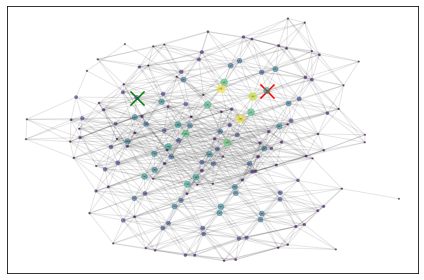

In [149]:
graphfun.display_graph(tgraph, blobs = bgraphs, extremes = egraphs)

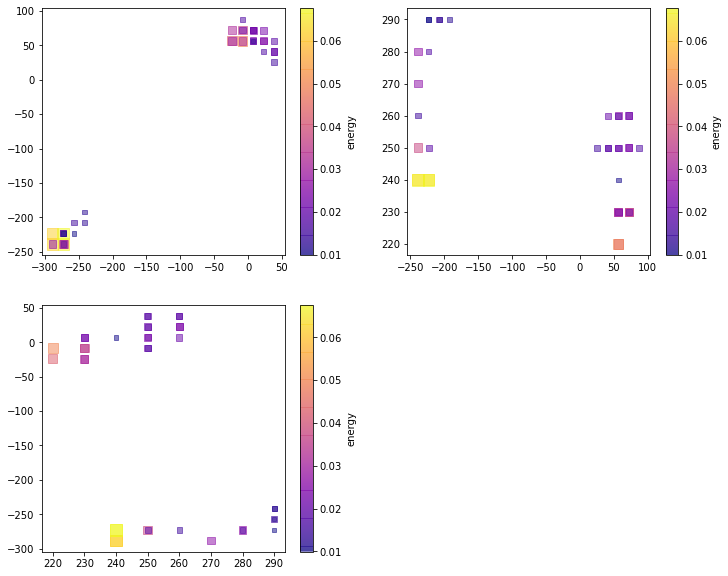

In [108]:
cmap = 'plasma'
cv = pltext.canvas(4, 2)
pos = graphfun.get_nodes_variable(g, 'position')
ene = graphfun.get_nodes_variable(g, 'energy')
xs = [[x[i] for x in pos] for i in range(3)]
for i, j in ((0, 1), (1, 2), (2, 0)):
    cv(i+1)
    plt.scatter(xs[i], xs[j], alpha = 0.5, c = ene, s = 2e3*ene, cmap = cmap, marker = 's')
    plt.colorbar(label = 'energy')

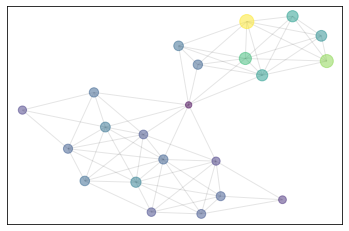

In [86]:
graphfun.display_graph(longest_graph)

In [ ]:
graph = nx.Graph()
graph.add_node(tuple(1, 1), energy = 1.)

TypeError: unhashable type: 'list'

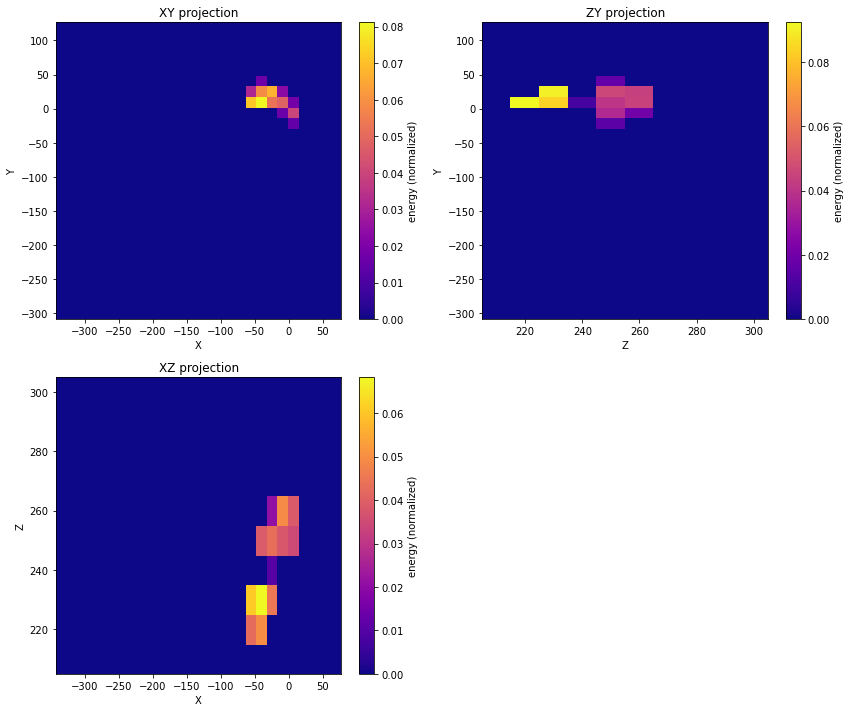

In [ ]:
graph = zevt['graph']
coors = graphfun.get_coors(longest_graph, bins)
enes  = graphfun.get_energy(longest_graph) 
zbins  = evtfun.get_bins(coors, bin_widths)
evtfun.event_display(coors, bins = bins, ene = enes);


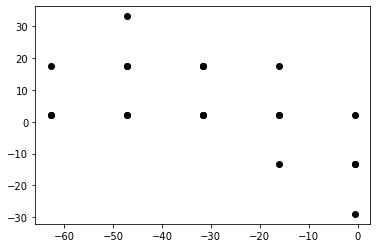

In [48]:
plt.scatter(coors[0], coors[1]);

In [39]:
ilabels   = [np.array([n[i] for n in list(longest_graph.nodes())]) for i in range(3)]
ilabels[0]

array([18, 18, 18, 19, 19, 19, 20, 20, 20, 19, 19, 20, 20, 20, 21, 21, 21,
       21, 22, 22, 22, 22])

In [34]:
coors

[array([-210.5]), array([-176.7]), array([10])]

In [32]:
vals = list(longest_graph.nodes())
vals[0]

(18, 20, 1)

In [ ]:
frm

## Run ZORA

In [161]:
print(mcfilename)

dataset_4bar_MC_DEP_deco.h5


In [186]:
dfout = zora.zora(ifilename = mcfilename, nevents = -1)

loading /mnt/netapp1/Store_next_data/NEXT100/deco_seg/dataset_4bar_MC_DEP_deco.h5
Number of events in input file 15038
Number of events to process 15037
Event 0
No extremes  [35] []
No extremes  [130] []
No extremes  [178] []
No extremes  [226] []
No extremes  [275] []
No extremes  [294] []
No extremes  [363] []
No extremes  [439] []
No extremes  [445] []
Event 500
No extremes  [552] []
No extremes  [638] []
No extremes  [646] []
No extremes  [742] []
No extremes  [744] []
No extremes  [860] []
No extremes  [865] []
No extremes  [906] []
No extremes  [970] []
Event 1000
No extremes  [1045] []
No extremes  [1057] []
No extremes  [1083] []
No extremes  [1133] []
No extremes  [1137] []
No extremes  [1155] []
No extremes  [1213] []
No extremes  [1222] []
No extremes  [1273] []
No extremes  [1347] []
No extremes  [1489] []
Event 1500
No extremes  [1504] []
No extremes  [1516] []
No extremes  [1571] []
No extremes  [1631] []
No extremes  [1636] []
No extremes  [1650] []
No extremes  [1673] [

In [187]:
dfout.head()

,ext_ene,ext_degree,ext_dist,blob_id,blob_ene,blob_nodes,blob_edges,blob_mcext_dist,blob_mcext_closenode,blob_mcseg,dataset_id,binclass,nhits,energy,spine_nhits,spine_energy,ngraphs,lgraph_nodes,lgraph_edges,lgraph_energy
0,0.005626,13,16,0,0.435297,72,584,0.000000,True,35.0,1,0,378,1.0,241,0.829546,2,240,1819,0.985380
1,0.001302,5,16,1,0.070860,24,140,11.224972,False,0.0,1,0,378,1.0,241,0.829546,2,240,1819,0.985380
2,0.000910,10,12,0,0.179905,40,277,5.830952,False,0.0,2,1,267,1.0,205,0.943462,7,199,1573,0.996518
3,0.000344,3,12,1,0.006244,6,13,2.236068,False,6.0,2,1,267,1.0,205,0.943462,7,199,1573,0.996518
4,0.004336,10,17,0,0.253746,33,236,0.000000,True,2.0,3,1,362,1.0,183,0.736879,2,182,1433,0.998303


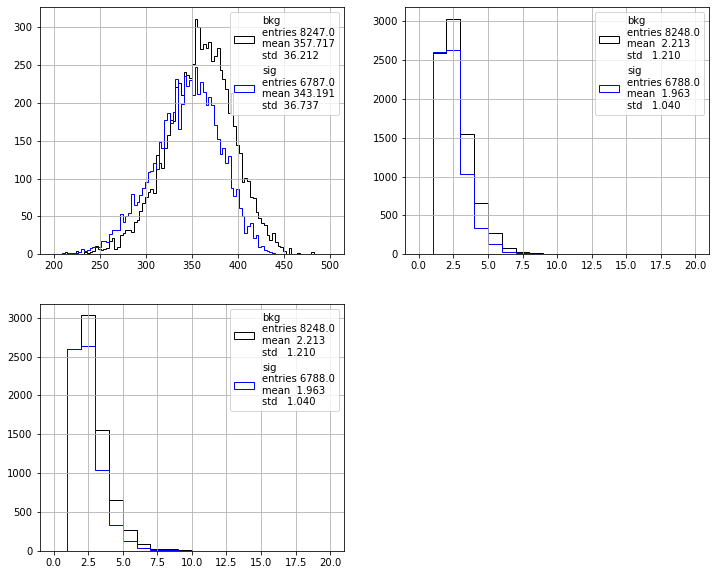

In [195]:
cv = pltext.canvas(4, 2)
seluni = dfout.blob_id == 1
selbkg = dfout.binclass == 0
selsig = dfout.binclass == 1

dfuni = dfout[seluni]

cv(1); 
pltext.hist(dfuni[selbkg].nhits, 100, (200, 500), label = 'bkg');
pltext.hist(dfuni[selsig].nhits, 100, (200, 500), label = 'sig');
cv(2); 
pltext.hist(dfuni[selbkg].ngraphs, 20, (0, 20), label = 'bkg');
pltext.hist(dfuni[selsig].ngraphs, 20, (0, 20), label = 'sig');
cv(3); 
pltext.hist(dfuni[selbkg].ngraphs, 20, (0, 20), label = 'bkg');
pltext.hist(dfuni[selsig].ngraphs, 20, (0, 20), label = 'sig');




In [190]:
vars = ['ext_ene',
 'ext_degree',
 'ext_dist',
 'blob_id',
 'blob_ene',
 'blob_nodes',
 'blob_edges',
 'blob_mcext_dist',
 'blob_mcseg',
 'dataset_id',
 'binclass',
 'nhits',
 'energy',
 'spine_nhits',
 'spine_energy',
 'ngraphs',
 'lgraph_nodes',
 'lgraph_edges',
 'lgraph_energy']

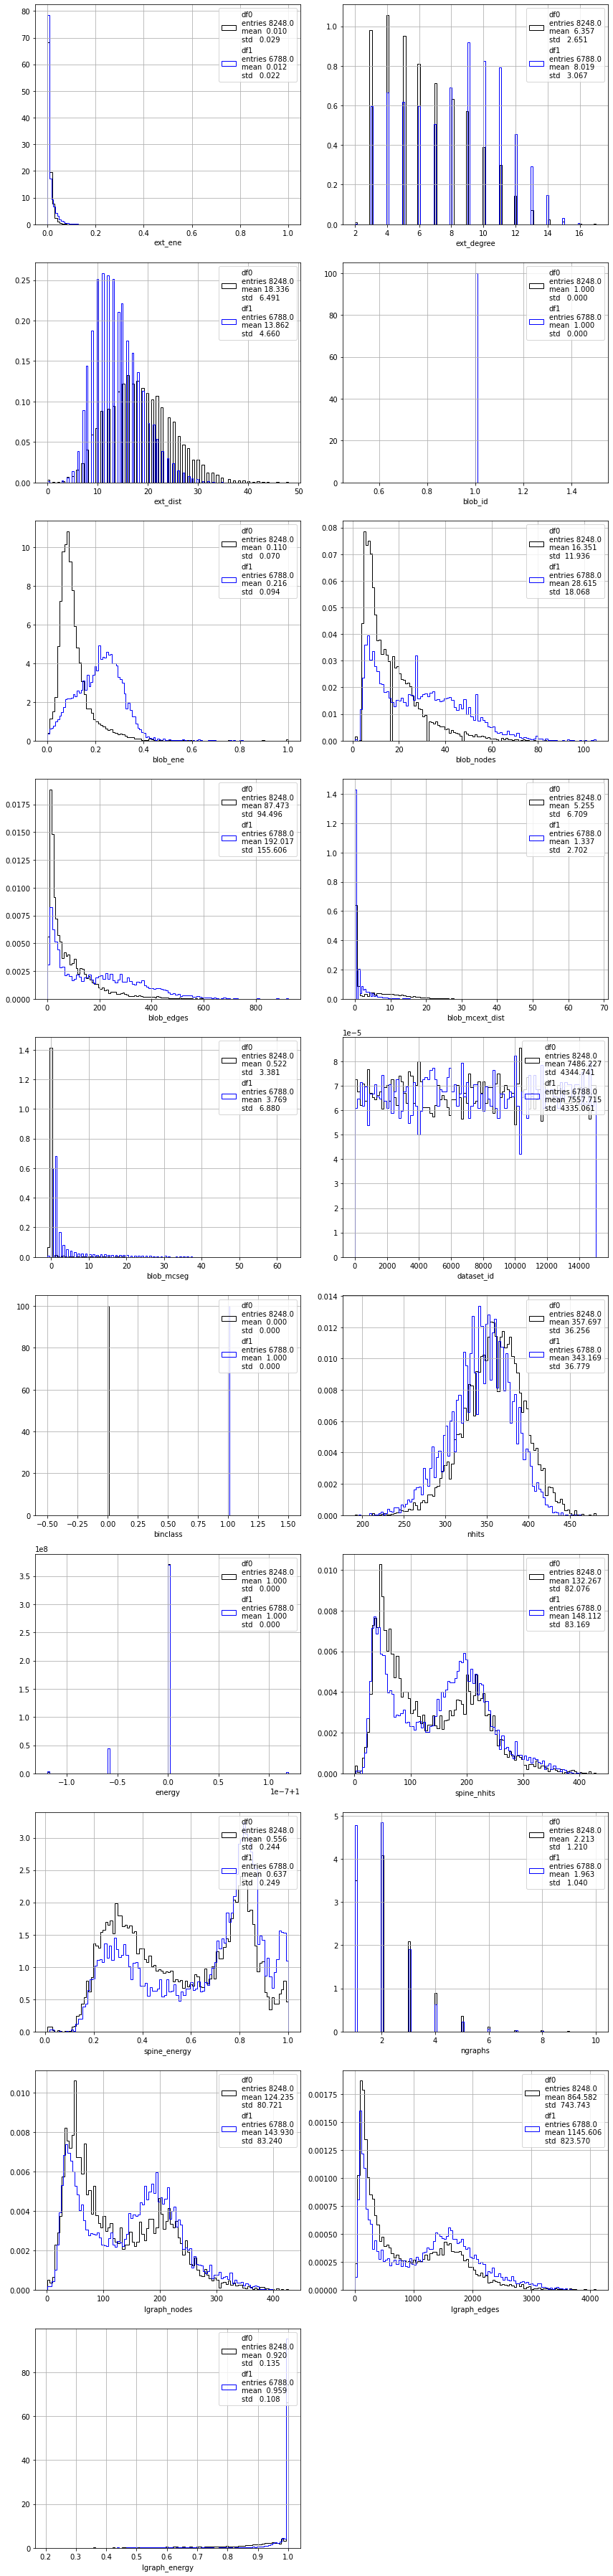

In [196]:
pltext.df_inspect((dfuni[selbkg], dfuni[selsig]), labels = vars, density = True)